# Average run length simulation

Distributions of alarm times for different target average run lengths ($\mathrm{ARL}_0 = 10, 100, 1000$) when using the `CUSUM` score. For each target the threshold is calibrated with `calibrate_threshold_arl`, null streams are simulated with the calibrated detector, and the distribution of individual run lengths is compared against the theoretical $\mathrm{Exp}$ approximation.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from gridcp import GridDetector
from gridcp.calibration import (
    calibrate_threshold_arl,
    mc_alarm_times,
    with_calibrated_threshold,
)
from gridcp.scores import CUSUM

## Simulation parameters

In [ ]:
# Warning: This simulation takes quite a long time (20 minutes+ on a MacBook pro with M5 pro chip) with N_SIM = 1_000_000,
# which is what we use in the paper.

TARGET_ARLS = [10, 100, 1000]  # target ARL_0 values
K_CAL = 10_000   # streams used to calibrate each threshold
N_SIM = 1_000_000   # streams used for obtaining alarm times
L_MAX_FACTOR = 10   # stream length for obtaining alarm times = L_MAX_FACTOR * target ARL
RNG_CAL, RNG_TEST = 0, 1
N_JOBS = 18 # Number of workers in the parallelized simulation code. Must be 18 to reproduce the exact results from the paper.

# Sampler function for sampling from the null, i.e. a standard normal distribution
def sampler(rng):
    return rng.standard_normal()

## Calibrate and simulate for each target ARL

In [ ]:
def run_arl_simulation(target_arl):
    """Calibrate, simulate null streams, and save run lengths for one target ARL."""
    score = CUSUM(enable_penalty=False)
    detector = GridDetector(score=score)

    # Calibrate threshold
    t0 = time.perf_counter()
    threshold = calibrate_threshold_arl(
        score,
        target_arl=target_arl,
        n_paths=K_CAL,
        pre_sampler=sampler,
        rng=RNG_CAL,
        n_jobs=N_JOBS
    )
    detector_cal = with_calibrated_threshold(detector, threshold)

    # Simulate alarm times
    stream_len = L_MAX_FACTOR * target_arl
    alarm_times = mc_alarm_times(
        detector_cal,
        N_SIM,
        stream_len,
        pre_sampler=sampler,
        rng=RNG_TEST,
        n_jobs=N_JOBS
    )
    print(f"Simulation for target ARL = {target_arl} finished in {time.perf_counter()-t0:.1f}s")

    return alarm_times

In [4]:
start_time = time.perf_counter()
sim_results = {}
for target_arl in TARGET_ARLS:
    sim_results[target_arl] = run_arl_simulation(target_arl)
print(f"Total simulation time: {time.perf_counter() - start_time:.1f}s")

Simulation for target ARL = 10 finished in 9.4s
Simulation for target ARL = 100 finished in 103.3s
Simulation for target ARL = 1000 finished in 1201.0s
Total simulation time: 1313.7s


## Plot distribution of run lengths per target ARL

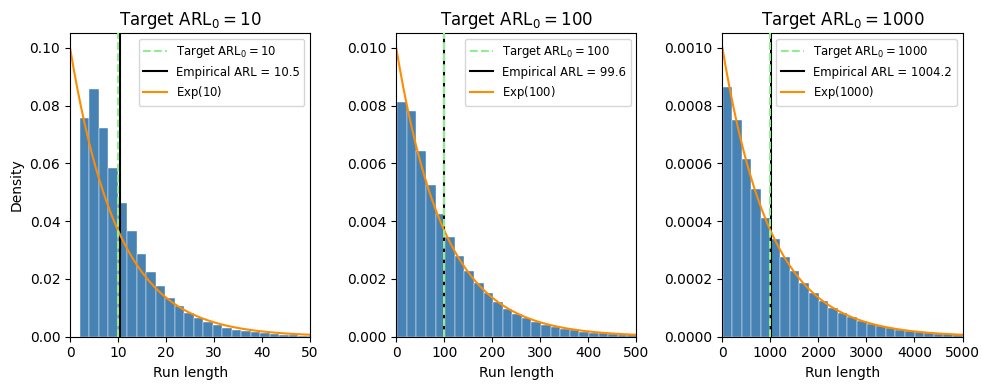

In [16]:
n_bins = 50

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, target in zip(axes, TARGET_ARLS):
    run_lengths = sim_results[target] + 1
    empirical_arl = float(np.mean(run_lengths))

    _, edges, _ = ax.hist(
        run_lengths,
        bins=n_bins,
        density=True,
        color="steelblue",
        edgecolor="white",
        linewidth=0.3,
    )
    ax.axvline(
        target,
        color="lightgreen",
        linestyle="--",
        linewidth=1.5,
        #alpha=0.6,
        zorder=3,
        label=rf"Target $\mathrm{{ARL}}_0 = {target}$",
    )
    ax.axvline(
        empirical_arl,
        color="k",
        linestyle="-",
        linewidth=1.5,
        #alpha=0.6,
        zorder=2,
        label=f"Empirical ARL = {empirical_arl:.1f}",
    )

    x = np.linspace(0.0, edges[-1], 400)
    exp_pdf = np.exp(-x / target) / target
    ax.plot(x, exp_pdf, color="darkorange", linewidth=1.5, label=rf"Exp(${target}$)")

    ax.set_xlabel("Run length")
    ax.set_title(rf"Target $\mathrm{{ARL}}_0 = {target}$")
    ax.set_xlim(0, 5 * target)
    ax.legend(fontsize="small")

axes[0].set_ylabel("Density")

plt.tight_layout()
plt.savefig("arl_dist_sim_grid.pdf", bbox_inches="tight")
plt.show()